# 3D Surface Visualization

__Author(s):__ Bernard Chang and Masa Prodanovic

__Last Update:__ Jan. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

## Objective

Segmented (also sometimes binary) images are those where each pixel or voxel has been classified as a member of a finite number of groups (phases, physical objects, elements or whatever is of interest to identify). We will here not spend more on the subject of segmentation (extremely important one!), but will use one such segmented image to plot surfaces between different phases (e.g. fluids, mineral phases in subsurface porous media) has already been made.

In 3D, it is very useful to draw surface that separates two phases or it is placed at an interpolated "level" of data. It is also called isosurface. Such surfaces in porous media are very complex, and consequently their 3D visualization (where what is shown is highly dependent on the viewer's position relative to the object being shown) is complex. For that reason, and due to constant software updates for pretty much anything, having a visualizer working is non-trivial. Jupyter notebooks, in addition, are attempting to add any visualization into the web-browser to seemlessly flow with the rest of the code and embedded Markdown text. Thus, if the images are not correctly embedded, using pyvista ina  regular Python environment is always an option. Just save this Notebook file (.ipynb) as a regular Python file (.py).


In [1]:
# Uncomment the following line to install dependencies locally
# %pip install --quiet --upgrade dpm_tools
import dpm_tools as dpm

# Some Utility functions
from pathlib import Path
import sys
sys.path.append("..")
from utils.dataloader import load_sample

# Image processsing
import numpy as np
import skimage.transform

# Image visualization
import matplotlib.pyplot as plt
import pyvista as pv

download_path = Path("/home/jovyan/work/ls6/dpm_teach_cache")

[15:17:43] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=117554;file://C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=375121;file://C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## 3D Visualization Warm-up

In this section, we will visualize a simple 3D elevation map. The same example will be demonstrated using both non-interactive Matplotlib and interactive PyVista.

### Using Matplotlib (Non-Interactive)
This is classical way to do 3D plots in Python shown here for reference. It always works because matplotlib is omnipresent, but the result is __not interactive__. For 3D data where visualization requires quite a bit of user input (there is no such thing as a default option working in most scientific 3D data visualization applications), this is barely adequate.

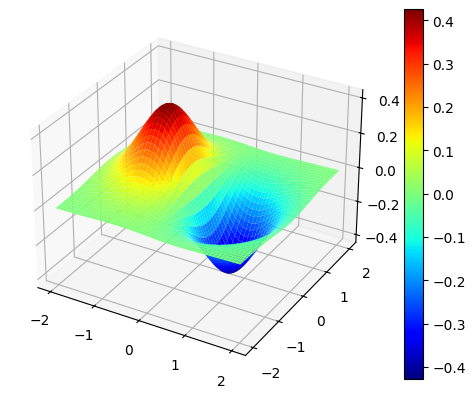

In [2]:
# Create data for surface plot
x=np.linspace(-2,2,100)
y = np.linspace(-2,2,100)

X,Y = np.meshgrid(x,y)

Z = -X*(np.exp(- X**2 - Y**2))

fig = plt.figure() #opens up empty figure

# tell the figure there will be a 3d projection
ax = fig.add_subplot(111,projection='3d')

# surface plot
surf = ax.plot_surface(X,Y,Z,cmap='jet')
# add colorbar
fig.colorbar(surf)

### Using PyVista (Interactive)

Matplotlib visualizations are static but it is hard to guess a good angle to look at a complex data, and interactive plots are more helpful in that regard. 

Here, we will exemplify PyVista — an open-source, Python library that provides toolsets for interactive 3D Visualization and mesh analysis. Though there are several other available 3D visualization libraries (e.g. Vedo, Mayavi, Matplotlib, etc.), PyVista is currently stable across all computing platforms and provides relatively clear documentation.

Documentation:
https://docs.pyvista.org/

In the following cell, we define a PyVista plotter object, which we can use to add our data to the plot.


In [3]:
# Enable interactive plotting within a Jupyter notebook requires a compatible backend.
# pythreejs is the smoothest that we have found (at this time), 
# but is missing some PyVista functionality
#
# ipyvtklink has all functionality, but is much slower
# If none of the backends work for interaction, you can use 'static' or export Python 
# file: executing regular Python script will open a separate window.
#pv.set_jupyter_backend('pythreejs')
pv.set_jupyter_backend('server')

# A function to initialize a PyVista Plotter Object
def initialize_plotter():
    
    # Initialize a PyVista Plotter Object
    plotter_obj = pv.Plotter()
    
    # Set the background color to white
    plotter_obj.set_background(color='w')
    pv.global_theme.font.color = 'black'
    
    return plotter_obj

To visualize our elevation plot, we need to define a PyVista ```StructuredGrid``` object and warp it by the scalar elevation values.

[Documentation](https://docs.pyvista.org/examples/00-load/create_structured_surface.html) on Python scripting that visualizes structured surface data in PyVista

In [4]:
# Make data
x=np.linspace(-2,2,500)
y = np.linspace(-2,2,500)
#print(x)
#print(y)

X,Y = np.meshgrid(x,y)
#print(X)
#print(Y)
Z = np.ones_like(X)
elevation = -X*(np.exp(- X**2 - Y**2))

# Create a structured grid
grid = pv.StructuredGrid(X, Y, Z)
# Add scalar to structured grid data for proper coloring — takes in 1D array. order='F' => Fortran-style ordering
grid['elevation'] = elevation.ravel(order='F')
# Warp operation modifies point coordinates by moving points along point normals by the scalar amount.
grid = grid.warp_by_scalar()

# Reinitialize plotter object
p = initialize_plotter()

# Add the structured grid as a mesh to the plotter object
p.add_mesh(grid, cmap='jet')

# Display the plot
p.show()



Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3b96dc3e0_0&reconnect=auto" class="pyvis…

## A Simple PyVista plot
Here, we will further explore PyVista data objects by demonstrating a structured grid represented with markers (or "glyphs") that vary in size.

The workflow for creating any PyVista plot can be generalized as follows:

1. Make sure the data you want to plot is a PyVista data object. In this example, we use a built-in PyVista function ```StructuredGrid``` to create a PyVista data object. We used the wrap function in the cell above to convert a NumPy array into the PyVista data object. Depending on how your data is formatted to begin with (e.g. VTK object), you may need to find alternate methods of creating a PyVista data object.
    
2. Initialize a plotter object

3. Create a mesh for the data you wish to plot (e.g. orthogonal slices, isosurfaces, etc.) and add the mesh to the plotter object

4. Use the ```show()``` function to display the plot in a self-contained plotter 

In [5]:
# Create data
# a 1D array
n = 4 
x = np.linspace(1,n,n)

# structured grid of n x n x n points (i.e. 3D) dictated by 1D array x
X, Y, Z = np.meshgrid(x,x,x)
grid = pv.StructuredGrid(X,Y,Z)

# Create varying radii based on glyph coordinates
r = np.sqrt(X*X + Y*Y + Z*Z)

# Add glyph radii to structured grid data — takes in 1D array
grid["radius"] = r.ravel()

# Initialize PyVista plotter object
p = initialize_plotter()

# Create a vtk sphere mesh to be plotted
sphere = pv.Sphere(radius=0.05, phi_resolution=50, theta_resolution=50)

# Use the vtk sphere mesh as glyphs, scaling each sphere by the 
# previously calculated radii
sphere_points = grid.glyph(scale="radius", geom=sphere)

# Add the glyphs as a mesh to the plotter object
p.add_mesh(sphere_points, cmap='jet')

# Display the plot
p.show()

C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\pyvista\core\filters\data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3aee82840_1&reconnect=auto" class="pyvis…

## Visualizing 3D Surfaces with PyVista

In the following example, we will use the PyVista library to visualize surfaces in a 3D image of a porous medium.

We will exemplify with a micro-CT image of an [oil blob trapped in a Ketton limestone pore sample](https://www.doi.org/10.17612/P7D95F) hosted on the Digital Porous Media Portal.

In the following cell, we load the sample and rescale it to a smaller size for faster processing.

In [6]:
image = load_sample('ketton_segmented')

print('Original image statistics\n')
dpm.metrics.histogram_statistics(image, plot_histogram=False)

image_rescaled  = skimage.transform.rescale(image.astype(float), 0.5, preserve_range=True)

# Wrap 3D NumPy array to PyVista data object
pv_img = pv.wrap(image_rescaled)

# check stats on rescaled image to make sure the values are preserved
print('Rescaled image statistics\n')
dpm.metrics.histogram_statistics(image, plot_histogram=False)

Loading cached sample 'ketton_segmented' from dpm_cache\ketton_segmented.tif
Original image statistics

-----------------------------------
Image statistics:
	Shape: (225, 255, 365)
	Data type: uint8
	Min: 1, Max:               3, Mean: 2.7589871967051662

Rescaled image statistics

-----------------------------------
Image statistics:
	Shape: (225, 255, 365)
	Data type: uint8
	Min: 1, Max:               3, Mean: 2.7589871967051662



[{'shape': (225, 255, 365),
  'dtype': dtype('uint8'),
  'min': np.uint8(1),
  'max': np.uint8(3),
  'mean': np.float64(2.7589871967051662),
  'median': np.float64(3.0),
  'variance': np.float64(0.31422753303809214),
  'skewness': np.float64(0.0),
  'kurtosis': np.float64(-1.200036621652552)}]

### Matplotlib slice visualization

This is a quick check to see what a slice through our Ketton limestone image looks like.

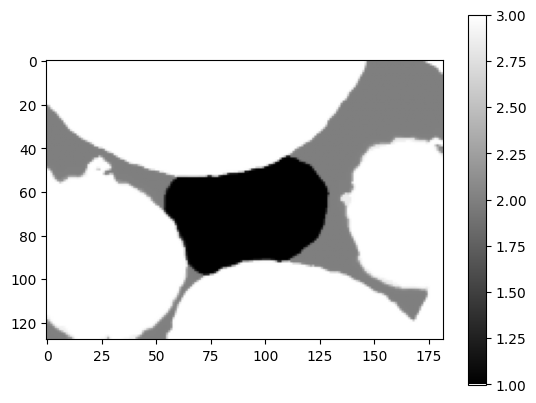

In [7]:
plt.imshow(image_rescaled[50,:,:], cmap='gray')
plt.colorbar()

## Plot Orthogonal Slices Through the Volume

Here, we will plot orthogonal slices through the 3D image of the oil blob trapped in the Ketton limestone.
### Using PyVista

In [8]:
# A function that plots orthogonal slices through the 3D image
def plot_orthogonal_slices(pv_image_obj, x_slice, y_slice, z_slice):
    ################################################################################ 
    # Input: PyVista image object (wrapped NumPy array), x, y, and z slices to plot
    # Output: PyVista plot of orthogonal slices
    ################################################################################
    
    # Initialize the PyVista plotter object
    p = initialize_plotter()
    
    # Tests to make sure input slices are within image dimensions
    assert x_slice > 0 and x_slice < pv_image_obj.dimensions[0], "X-slice value outside image dimensions"
    assert y_slice > 0 and y_slice < pv_image_obj.dimensions[1], "Y-slice value outside image dimensions"
    assert z_slice > 0 and z_slice < pv_image_obj.dimensions[2], "Z-slice value outside image dimensions"
    
    # Create three orthogonal slices through the dataset at specified X, Y, and Z values
    slices = pv_image_obj.slice_orthogonal(x=x_slice, y=y_slice, z=z_slice)
    
    # Add the slices as meshes to the PyVista plotter object
    p.add_mesh(slices)
    
    # Display the plot
    p.show()


# Get dimensions of the rescaled image
x_dim, y_dim, z_dim = pv_img.dimensions

# Function call to plot the orthogonal slices.
plot_orthogonal_slices(pv_img, x_dim//2 , y_dim//2, z_dim//2)


Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bd65e660_2&reconnect=auto" class="pyvis…

### Using DPM Tools

DPM Tools provides a wrapper function, ```plot_orthogonal_slices()```, that simplifies working with PyVista by handling the underlying plotting logic.

In [9]:
ketton_oil_blob = dpm.io.Image(scalar=image_rescaled)
p = dpm.visualization.orthogonal_slices(ketton_oil_blob, slider=False)
p.show(jupyter_backend="server")

Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bd678380_3&reconnect=auto" class="pyvis…

## Plotting Isosurfaces
### Oil blob surface

In the segmented image, we have 1, 2 and 3 represent oil, brine and rock respectively.

The interpolated value of 1.5 separated oil from everything else.

In [10]:
# Reinitialize plotter object
p = initialize_plotter()

# Generate a contoured surface at the explicitly specified isosurface value. 
oil_isosurface = pv_img.contour(isosurfaces=[1.5])

# Add the contoured surface as a mesh to the PyVista plotter object
# Color can be specified as a string (e.g. 'green'), RGB list, or hex color string
# Opacity is a single float value between 0 and 1 (inclusive). 
p.add_mesh(oil_isosurface, color=[0, 0.8, 0.27], opacity=1.)

# Display the plot
p.show()


Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bda68d70_4&reconnect=auto" class="pyvis…

#### Pore-grain surface

Recall that the segmented image represents oil, brine and rock with values of 1, 2 and 3 respectively.
The surface passing through points where interpolated image values are 2.5 is a surface that separates both fluids and the rock. 



In [11]:
p = initialize_plotter()

# Generate a contoured surface at the explicitly specified isosurface value.
grain_isosurface = pv_img.contour(isosurfaces=[2.5])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(153, 255, 255), opacity=0.8)

# Display the plot
p.show()

Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bda82ae0_5&reconnect=auto" class="pyvis…

#### Oil blob and pore-grain surface together

To plot the oil blob and grain surface together (and any other phase that might be present), you can simply keep adding meshes to the same initial plotter object. 

In [12]:
# Reinitialize the Plotter object
p = initialize_plotter()

# Extract the oil surface contour and add the mesh to the Plotter object
oil_surface = pv_img.contour(isosurfaces=[1.5])
p.add_mesh(oil_surface, color=[0, 0.8, 0.27], opacity=0.5)

# Extract the grain surface contour and add the mesh to the Plotter object
grain_surface = pv_img.contour(isosurfaces=[2.5])
p.add_mesh(grain_surface, color=(153, 255, 255), opacity=0.5)

# Display the axes orientation widget (Will not show up if using pythreejs backend)
p.show_axes()

# Display the plot
p.show()

Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bda90980_6&reconnect=auto" class="pyvis…

### Using DPM Tools

DPM Tools also provides a wrapper function, ```dpm_tools.visualization.plot_isosurface()```, that abstracts the PyVista isosurface plotting. 

In [13]:
p = dpm.visualization.plot_isosurface(ketton_oil_blob, show_isosurface=[1.5], mesh_kwargs={"color":[0, 0.8, 0.27], "opacity":0.5})
dpm.visualization.plot_isosurface(ketton_oil_blob, show_isosurface=[2.5], mesh_kwargs={"color":[153, 255, 255], 'opacity':0.5}, fig=p)
p.show(jupyter_backend="server")

Widget(value='<iframe src="http://localhost:53742/index.html?ui=P_0x2c3bda92150_7&reconnect=auto" class="pyvis…